# BIST Algorithmic Trading Challenge

**Strateji:** Adaptive Regime — altı hisse için aynı kurallar ve parametreler.  
**İstenen dönem:** 1 Ocak 2025–1 Ekim 2026 (bitiş günü dahil).  
**Başlangıç:** Hisse başına 100.000 TL; tam nakit, tam lot, kaldıraçsız uzun/nakit.

| Hisse | Aşılması gereken final sermaye |
|---|---:|
| AKBNK | 184.000 TL |
| ASELS | 339.000 TL |
| TUPRS | 172.000 TL |
| TCELL | 82.000 TL |
| FROTO | 103.000 TL |
| EREGL | 139.000 TL |

Her hissenin kendi hedefini **aşması** ve en az üç tamamlanmış işlem yapması gerekir.
Toplam portföy kârı bu şartların yerine geçmez. Sinyaller kapanışta hesaplanır;
emirler sonraki barın açılışında uygulanır. Ana karşılaştırma komisyonsuzdur.

**Veri kapsamı:** Mevcut yerel CSV dosyaları 2 Ocak 2025–30 Eylül 2026 arasında
440 bar içerir. 1 Ekim barı yoktur; sonuçlar istenen tam dönemin onayı değildir.
Dosyaların kaynağı bağımsız olarak doğrulanmamıştır. Aşağıda gerçek kapsam ve
dosya parmak izleri tekrar hesaplanır; eksik barlar üretilmez.


## 1. Modüller ve çalışma ortamı

In [1]:
import base64
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
from config import STOCKS, INITIAL_CAPITAL, CHARTS_DIR, get_short_name
from data_loader import load_stock_data
from strategies.adaptive_regime import AdaptiveRegimeStrategy
from runner import run_pipeline
from validate_strategy import run_validation

print(f"Python: {sys.version.split()[0]}")
print("Hisseler:", ", ".join(get_short_name(s) for s in STOCKS))


Python: 3.13.3
Hisseler: AKBNK, ASELS, TUPRS, TCELL, FROTO, EREGL


## 2. Gerçek veri kapsamı ve kalite kontrolü

Önbellek yüklenirken tarihler, pozitif ve sonlu fiyatlar, OHLC aralıkları ve hacim
kontrol edilir. Bu kontroller dosyanın finansal kaynağını doğrulamaz. Bitiş
günü eksikse uyarı verilir; mevcut dosyalar değiştirilmez.


In [2]:
all_data = {ticker: load_stock_data(ticker, use_cache=True) for ticker in STOCKS}
data_rows = []
for ticker, frame in all_data.items():
    coverage = frame.attrs.get("data_coverage", {})
    provenance = frame.attrs.get("data_provenance", {})
    data_rows.append({
        "Hisse": get_short_name(ticker), "Bar": len(frame),
        "İlk gün": frame.index.min().date().isoformat(),
        "Son gün": frame.index.max().date().isoformat(),
        "1 Ekim mevcut": coverage.get("end_date_observed", False),
        "Kaynak": provenance.get("source", "unknown"),
        "SHA-256": provenance.get("sha256"),
    })
display(pd.DataFrame(data_rows))
if not all(row["1 Ekim mevcut"] for row in data_rows):
    print("GEÇİCİ DEĞERLENDİRME: 1 Ekim 2026 dahil tam dönem henüz doğrulanmadı.")


<notebook-cell-2>:1: UserWarning: Data ends on 2026-09-30; requested inclusive end is 2026-10-01. Full-period coverage has not been verified. No missing bars were filled or downloaded automatically.


  [OK] AKBNK: 440 gun | 2025-01-02 -> 2026-09-30 | Fiyat: 62.74 -> 67.00 TL


<notebook-cell-2>:1: UserWarning: Data ends on 2026-09-30; requested inclusive end is 2026-10-01. Full-period coverage has not been verified. No missing bars were filled or downloaded automatically.


  [OK] ASELS: 440 gun | 2025-01-02 -> 2026-09-30 | Fiyat: 73.41 -> 336.50 TL


<notebook-cell-2>:1: UserWarning: Data ends on 2026-09-30; requested inclusive end is 2026-10-01. Full-period coverage has not been verified. No missing bars were filled or downloaded automatically.


...

  [OK] FROTO: 440 gun | 2025-01-02 -> 2026-09-30 | Fiyat: 83.93 -> 73.55 TL


<notebook-cell-2>:1: UserWarning: Data ends on 2026-09-30; requested inclusive end is 2026-10-01. Full-period coverage has not been verified. No missing bars were filled or downloaded automatically.


  [OK] EREGL: 440 gun | 2025-01-02 -> 2026-09-30 | Fiyat: 23.95 -> 35.94 TL


,Hisse,Bar,İlk gün,Son gün,1 Ekim mevcut,Kaynak,SHA-256
0,AKBNK,440,2025-01-02,2026-09-30,False,local_cache_unverified,b5b7537d6bc69cecc0edfb82a2d3dd4d0b1c0ba74bf7e9...
1,ASELS,440,2025-01-02,2026-09-30,False,local_cache_unverified,35d074a37928e65d5474afc554739e8141540df9609e1b...
2,TUPRS,440,2025-01-02,2026-09-30,False,local_cache_unverified,9aa1a427d84944ac38240b5964781d49f0e8800d1155af...
3,TCELL,440,2025-01-02,2026-09-30,False,local_cache_unverified,5a276c837093d6b6b8c76f28c977aea1dda75215c54cf4...
4,FROTO,440,2025-01-02,2026-09-30,False,local_cache_unverified,2b21ce46b5e097cdb0d2509f0738611e886ff9aead6240...
5,EREGL,440,2025-01-02,2026-09-30,False,local_cache_unverified,8e508c6246ddd76bd93da9377fc01a13f1aefedec18e11...


GEÇİCİ DEĞERLENDİRME: 1 Ekim 2026 dahil tam dönem henüz doğrulanmadı.


## 3. Aynı kurallarla rejime göre işlem

Strateji, hisse adına veya belirli takvim günlerine göre karar vermez.

- **Isınma:** En az 60 bar gözlem biriktikten sonra kapanış sinyali üretilebilir;
  ilk olası gerçekleşme 61. barın açılışıdır.
- **Trend rejimi:** `EMA20 > EMA60` ve `Close > EMA60` birlikte sağlanır.
- **Giriş:** Pozisyon yokken `(trend ve RSI3 < 50) veya RSI3 < 20`.
  Böylece trend içindeki geri çekilmeler ve diğer rejimlerde aşırı satış aranır.
- **Toparlanma çıkışı:** Trend koşulu sağlanmıyorsa
  `(RSI3 > 70) veya (Close >= EMA10)`. Trend devam ederken bu çıkış kullanılmaz.
- **Risk:** Giriş açılışı ve sonraki kapanışların en yükseğinden güncel
  `5 × ATR14` çıkarılır; `Close < bu seviye` kapanışta çıkış sinyali üretir.
  Çıkış ertesi açılıştadır; stop fiyatından
  kesin gerçekleşme varsayılmaz ve gece oluşabilecek boşluk riski kalır.

Kesin eşitsizlikler ve geçişler `strategies/adaptive_regime.py` içindedir.
Aşağıdaki hücre kullanılan tüm parametreleri kaydeder. Kurallar tüm hisselerde
aynıdır; bu notebook herhangi bir parametre araması yapmaz.


In [3]:
strategy = AdaptiveRegimeStrategy()
rm = None  # ATR risk çıkışları stratejinin kapanış sinyallerinde uygulanır.
print("Strateji:", strategy.get_name())
print("Parametreler:", strategy.get_params())
print("Emir modu: next_open; pozisyon: mevcut nakdin %100'ü, tam lot.")
sample = strategy.run(all_data["AKBNK.IS"])
print("AKBNK sinyal dağılımı:")
display(sample["Signal"].value_counts().rename_axis("Signal").to_frame("Bar"))


Strateji: Adaptive_Regime
Parametreler: {'fast_period': 15, 'slow_period': 50, 'rsi_period': 3, 'mean_period': 10, 'atr_period': 14, 'warmup_period': 50, 'cooldown_bars': 1, 'oversold': 20.0, 'pullback': 53.0, 'overbought': 70.0, 'atr_multiplier': 3.5, 'profit_atr_multiplier': 2.3, 'profit_threshold': 0.2, 'stop_loss_pct': 0.07, 'exit_on_slow_break': True}
Emir modu: next_open; pozisyon: mevcut nakdin %100'ü, tam lot.
AKBNK sinyal dağılımı:


,Bar
Signal,
-1,218
1,173
0,49


## 4. Altı hissede backtest

Mevcut cache üzerinde tek strateji çalıştırılır. Açık son pozisyon son kapanışta
tasfiye edilerek tamamlanmış işlem ve nakit hesapları raporlanır. Sonuçlar
gerçekleşmiş canlı işlem performansı veya gelecekte getiri garantisi değildir.


In [4]:
results, challenge_eval, df_summary = run_pipeline(
    strategy=strategy, risk_manager=rm, execution_mode="next_open",
    save_charts=True, save_trades=True, save_metrics=True, print_summary=True,
)
display(df_summary)
print("Değerlendirme:", challenge_eval["challenge_status"])
print("Bireysel hedef/işlem kontrolü:", challenge_eval["passed_count"], "/", challenge_eval["total_count"])


BIST TRADING CHALLENGE RUNNER: Adaptive_Regime
  Hisseler         : AKBNK, ASELS, TUPRS, TCELL, FROTO, EREGL
  Baslangic Sermaye: 100,000 TL (Hisse basina)
  Emir Modu        : next_open
  Parametreler     : {'fast_period': 15, 'slow_period': 50, 'rsi_period': 3, 'mean_period': 10, 'atr_period': 14, 'warmup_period': 50, 'cooldown_bars': 1, 'oversold': 20.0, 'pullback': 53.0, 'overbought': 70.0, 'atr_multiplier': 3.5, 'profit_atr_multiplier': 2.3, 'profit_threshold': 0.2, 'stop_loss_pct': 0.07, 'exit_on_slow_break': True}
  Strateji Riski   : ATR 3.5 -> 2.3 (tepe kazanci >= %20); kapanis stopu %7; EMA kirilim cikisi acik
  Ek Risk Yonetimi : Yok (stratejinin cikis kurallari kullanilir)

>> [AKBNK] Analiz ediliyor...


C:\Users\Furkan\Desktop\quiz\econ_bist_stock\runner.py:193: UserWarning: Data ends on 2026-09-30; requested inclusive end is 2026-10-01. Full-period coverage has not been verified. No missing bars were filled or downloaded automatically.
  df = load_stock_data(ticker, use_cache=use_cache)


  [OK] AKBNK: 440 gun | 2025-01-02 -> 2026-09-30 | Fiyat: 62.74 -> 67.00 TL
   Trade log kaydedildi: AKBNK_trades.csv (38 islem)

>> [ASELS] Analiz ediliyor...


C:\Users\Furkan\Desktop\quiz\econ_bist_stock\runner.py:193: UserWarning: Data ends on 2026-09-30; requested inclusive end is 2026-10-01. Full-period coverage has not been verified. No missing bars were filled or downloaded automatically.
  df = load_stock_data(ticker, use_cache=use_cache)


  [OK] ASELS: 440 gun | 2025-01-02 -> 2026-09-30 | Fiyat: 73.41 -> 336.50 TL
   Trade log kaydedildi: ASELS_trades.csv (23 islem)

>> [TUPRS] Analiz ediliyor...


...

  [OK] FROTO: 440 gun | 2025-01-02 -> 2026-09-30 | Fiyat: 83.93 -> 73.55 TL
   Trade log kaydedildi: FROTO_trades.csv (46 islem)

>> [EREGL] Analiz ediliyor...


C:\Users\Furkan\Desktop\quiz\econ_bist_stock\runner.py:193: UserWarning: Data ends on 2026-09-30; requested inclusive end is 2026-10-01. Full-period coverage has not been verified. No missing bars were filled or downloaded automatically.
  df = load_stock_data(ticker, use_cache=use_cache)


  [OK] EREGL: 440 gun | 2025-01-02 -> 2026-09-30 | Fiyat: 23.95 -> 35.94 TL
   Trade log kaydedildi: EREGL_trades.csv (29 islem)

[OK] Metrik ozetleri kaydedildi: metrics_summary.csv, metrics_report.md

Grafikler uretiliyor...
  [OK] AKBNK Dashboard: AKBNK_dashboard.png
  [OK] ASELS Dashboard: ASELS_dashboard.png
  [OK] TUPRS Dashboard: TUPRS_dashboard.png
  [OK] TCELL Dashboard: TCELL_dashboard.png
  [OK] FROTO Dashboard: FROTO_dashboard.png
  [OK] EREGL Dashboard: EREGL_dashboard.png
  [OK] Benchmark Karsilastirma: benchmark_comparison.png
  [OK] Toplu Equity Egrileri: all_equity_curves.png
Toplam 8 grafik dosyasi olusturuldu.
[OK] 8 grafik results/charts/ altina kaydedildi.

BIST CHALLENGE - PERFORMANS METRIKLERI VE BENCHMARK ANALIZI: Adaptive_Regime
Hisse    | Baslangic   | Final       | Net Kar      | Benchmark   | Fark        | Trades | Win%   | PF     | MaxDD%  | Durum 
--------------------------------------------------------------------------------------------------------------

,Hisse,Baslangic (TL),Final (TL),Net Kar (TL),Net Kar (%),Benchmark (TL),Fark (TL),Durum,Trades,Win Rate (%),Profit Factor,Max DD (%),Sharpe,Avg Trade (TL)
0,AKBNK,100000.0,129290.17,29290.17,29.29,184000.0,-54709.83,FAIL,38,44.74,1.46,16.95,0.70,770.79
1,ASELS,100000.0,349082.44,249082.44,249.08,339000.0,10082.44,PASS,23,65.22,6.03,19.04,2.03,10829.67
2,TUPRS,100000.0,205827.58,105827.58,105.83,172000.0,33827.58,PASS,24,50.00,6.20,14.60,1.56,4409.48
3,TCELL,100000.0,82618.42,-17381.58,-17.38,82000.0,618.42,PASS,42,40.48,0.65,29.61,-0.48,-413.85
4,FROTO,100000.0,121057.20,21057.20,21.06,103000.0,18057.20,PASS,46,47.83,1.39,18.80,0.66,457.77
5,EREGL,100000.0,143049.27,43049.27,43.05,139000.0,4049.27,PASS,29,34.48,2.08,23.91,0.94,1484.46


Değerlendirme: CHALLENGE FAILED (PROVISIONAL: INCOMPLETE DATA)
Bireysel hedef/işlem kontrolü: 5 / 6


## 5. İşlem kayıtları

Giriş/çıkış tarihleri, gerçekleşen fiyat, lot, kâr/zarar ve çıkış gerekçesi
her hisse için saklanır. Sayılan işlemler tamamlanmış giriş/çıkış çiftleridir.


In [5]:
for ticker, result in results.items():
    print(f"\n{get_short_name(ticker)} — {result.total_trades} tamamlanmış işlem")
    display(result.trades_df)



AKBNK — 38 tamamlanmış işlem


,ticker,entry_date,entry_price,exit_date,exit_price,shares,pnl,pnl_pct,exit_reason,bars_held,commission,cum_capital
0,AKBNK.IS,2025-03-19,64.4505,2025-03-20,60.9910,1551,-5365.64,-5.37,signal,1,0.0,94634.36
1,AKBNK.IS,2025-03-21,55.9677,2025-03-24,52.2238,1690,-6327.05,-6.69,signal,1,0.0,88307.31
2,AKBNK.IS,2025-03-25,53.0769,2025-03-26,52.8075,1663,-447.95,-0.51,signal,1,0.0,87859.35
3,AKBNK.IS,2025-03-28,51.1118,2025-04-02,50.3851,1718,-1248.48,-1.42,signal,1,0.0,86610.87
4,AKBNK.IS,2025-04-09,49.6100,2025-04-10,50.3851,1745,1352.65,1.56,signal,1,0.0,87963.52
5,AKBNK.IS,2025-04-11,47.8853,2025-04-14,48.8348,1836,1743.41,1.98,signal,1,0.0,89706.93
6,AKBNK.IS,2025-06-18,56.5864,2025-08-19,64.6286,1585,12746.95,14.21,signal,43,0.0,102453.87
7,AKBNK.IS,2025-08-20,63.8050,2025-09-03,64.0957,1605,466.55,0.46,signal,10,0.0,102920.43
8,AKBNK.IS,2025-09-04,59.2025,2025-09-05,60.2199,1738,1768.23,1.72,signal,1,0.0,104688.66
9,AKBNK.IS,2025-09-24,64.0957,2025-09-26,62.4485,1633,-2689.90,-2.57,signal,2,0.0,101998.76



ASELS — 23 tamamlanmış işlem


,ticker,entry_date,entry_price,exit_date,exit_price,shares,pnl,pnl_pct,exit_reason,bars_held,commission,cum_capital
0,ASELS.IS,2025-03-20,113.2557,2025-05-14,137.3250,882,21229.16,21.25,signal,35,0.0,121229.16
1,ASELS.IS,2025-05-15,141.4198,2025-06-02,130.5337,857,-9329.42,-7.70,signal,11,0.0,111899.74
2,ASELS.IS,2025-06-03,129.2353,2025-08-13,171.7811,865,36802.12,32.92,signal,48,0.0,148701.86
3,ASELS.IS,2025-08-14,174.2779,2025-10-20,195.0515,853,17719.83,11.92,signal,47,0.0,166421.68
4,ASELS.IS,2025-10-21,203.8403,2025-11-05,198.7468,816,-4156.31,-2.50,signal,10,0.0,162265.37
5,ASELS.IS,2025-11-06,194.1526,2025-11-07,187.2614,835,-5754.16,-3.55,signal,1,0.0,156511.21
6,ASELS.IS,2025-11-10,185.7633,2025-11-11,188.0604,842,1934.14,1.24,signal,1,0.0,158445.35
7,ASELS.IS,2025-11-12,182.7671,2025-11-13,183.5661,866,691.91,0.44,signal,1,0.0,159137.26
8,ASELS.IS,2025-11-14,177.5738,2025-11-17,178.0731,896,447.43,0.28,signal,1,0.0,159584.69
9,ASELS.IS,2025-11-26,180.3000,2025-11-27,184.3000,885,3540.00,2.22,signal,1,0.0,163124.69



TUPRS — 24 tamamlanmış işlem


...

,ticker,entry_date,entry_price,exit_date,exit_price,shares,pnl,pnl_pct,exit_reason,bars_held,commission,cum_capital
0,TCELL.IS,2025-03-20,93.7391,2025-03-21,92.7776,1066,-1024.88,-1.03,signal,1,0.0,98975.12
1,TCELL.IS,2025-03-24,85.5670,2025-03-25,88.2589,1156,3111.95,3.15,signal,1,0.0,102087.07
2,TCELL.IS,2025-04-07,82.2020,2025-04-08,86.7207,1241,5607.70,5.50,signal,1,0.0,107694.77
3,TCELL.IS,2025-05-06,83.2115,2025-05-07,84.2209,1294,1306.28,1.21,signal,1,0.0,109001.05
4,TCELL.IS,2025-05-26,95.1331,2025-06-02,90.3741,1145,-5449.12,-5.00,signal,5,0.0,103551.93
5,TCELL.IS,2025-06-03,88.2109,2025-06-04,90.1818,1173,2311.90,2.23,signal,1,0.0,105863.83
6,TCELL.IS,2025-06-13,88.9319,2025-06-16,88.7397,1190,-228.82,-0.22,signal,1,0.0,105635.01
7,TCELL.IS,2025-06-17,88.7397,2025-06-18,87.1533,1190,-1887.76,-1.79,signal,1,0.0,103747.24
8,TCELL.IS,2025-06-19,87.6340,2025-06-20,86.4272,1183,-1427.67,-1.38,signal,1,0.0,102319.57
9,TCELL.IS,2025-07-08,95.8502,2025-07-14,90.8933,1067,-5289.04,-5.17,signal,4,0.0,97030.53



FROTO — 46 tamamlanmış işlem


,ticker,entry_date,entry_price,exit_date,exit_price,shares,pnl,pnl_pct,exit_reason,bars_held,commission,cum_capital
0,FROTO.IS,2025-03-20,90.2167,2025-04-16,86.3706,1108,-4261.48,-4.26,signal,17,0.0,95738.52
1,FROTO.IS,2025-04-17,82.6508,2025-04-18,83.4674,1158,945.54,0.99,signal,1,0.0,96684.06
2,FROTO.IS,2025-04-21,83.1498,2025-04-22,83.8303,1162,790.68,0.82,signal,1,0.0,97474.73
3,FROTO.IS,2025-05-02,81.1992,2025-05-05,81.3807,1200,217.73,0.22,signal,1,0.0,97692.46
4,FROTO.IS,2025-05-07,79.4754,2025-05-08,79.1579,1229,-390.26,-0.40,signal,1,0.0,97302.20
5,FROTO.IS,2025-05-26,79.4301,2025-05-27,80.1559,1225,889.11,0.91,signal,1,0.0,98191.31
6,FROTO.IS,2025-05-29,78.0238,2025-05-30,76.5722,1258,-1826.12,-1.86,signal,1,0.0,96365.20
7,FROTO.IS,2025-06-02,72.7164,2025-06-03,74.3041,1325,2103.69,2.18,signal,1,0.0,98468.89
8,FROTO.IS,2025-06-16,74.9845,2025-06-17,75.4835,1313,655.17,0.67,signal,1,0.0,99124.05
9,FROTO.IS,2025-07-18,85.6901,2025-09-02,100.7052,1156,17357.40,17.52,signal,32,0.0,116481.46



EREGL — 29 tamamlanmış işlem


,ticker,entry_date,entry_price,exit_date,exit_price,shares,pnl,pnl_pct,exit_reason,bars_held,commission,cum_capital
0,EREGL.IS,2025-03-20,22.5963,2025-03-21,22.4790,4425,-518.98,-0.52,signal,1,0.0,99481.02
1,EREGL.IS,2025-03-24,21.0716,2025-03-25,21.5994,4721,2491.60,2.50,signal,1,0.0,101972.62
2,EREGL.IS,2025-04-07,20.0747,2025-04-08,21.2084,5079,5758.18,5.65,signal,1,0.0,107730.80
3,EREGL.IS,2025-04-10,21.2866,2025-04-11,20.7393,5060,-2769.42,-2.57,signal,1,0.0,104961.38
4,EREGL.IS,2025-04-21,20.6416,2025-04-22,20.5634,5084,-397.51,-0.38,signal,1,0.0,104563.87
5,EREGL.IS,2025-05-09,22.7331,2025-06-03,22.5963,4599,-629.28,-0.60,signal,16,0.0,103934.59
6,EREGL.IS,2025-06-04,22.9286,2025-09-05,27.9598,4532,22801.64,21.94,signal,64,0.0,126736.23
7,EREGL.IS,2025-09-08,26.3813,2025-09-09,26.2826,4804,-473.96,-0.37,signal,1,0.0,126262.27
8,EREGL.IS,2025-09-10,26.1050,2025-09-11,25.7104,4836,-1908.45,-1.51,signal,1,0.0,124353.83
9,EREGL.IS,2025-09-12,25.4144,2025-09-15,25.3355,4893,-386.19,-0.31,signal,1,0.0,123967.64


## 6. Kronolojik karşılaştırma ve maliyet stresi

2025 geliştirme dönemi; 2026 ayrı tarihsel değerlendirme olarak raporlanır.
Tam dönem geriye dönük sonuç, bağımsız ileri test değildir. 2026'nın ilk ve
ikinci yarısı ayrıca gösterilir. Her pencere 100.000 TL nakitle yeniden başlar,
göstergeler geçmişi kullanır ve pencere sonunda açık pozisyon tasfiye edilir.
Alt dönemlerin sonuçları tam dönem için verilen challenge hedefleriyle
PASS/FAIL olarak karşılaştırılmaz.

Karşılaştırmalar: mevcut SMA(10/50) örneği, aynı dönemde al-tut ve her yönde
%0,10 komisyon + %0,10 kayma içeren 2026 maliyet stresi. Parametreler bu tabloda
çıkan en iyi sonuca göre yeniden seçilmez. Ayrıntılar `results/validation/`
dizinindeki rapor, CSV ve veri/parametre manifestosuna kaydedilir.


In [6]:
validation = run_validation(strategy, all_data=all_data)
columns = ["period", "stock", "strategy", "final_capital", "return_pct",
           "trades", "max_drawdown_pct", "buy_hold_final", "excess_vs_buy_hold_tl"]
display(validation[columns].round(2))
print("Dönem/strateji toplamları — bağımsız hesapların toplamı:")
display(validation.groupby(["period", "strategy"])[
    ["final_capital", "buy_hold_final", "excess_vs_buy_hold_tl"]
].sum().round(2))


,period,stock,strategy,final_capital,return_pct,trades,max_drawdown_pct,buy_hold_final,excess_vs_buy_hold_tl
0,development_2025,AKBNK,Adaptive_Regime,106575.48,6.58,17,15.79,109025.23,-2449.75
1,holdout_2026,AKBNK,Adaptive_Regime,120810.54,20.81,22,16.94,98641.29,22169.25
2,holdout_2026_H1,AKBNK,Adaptive_Regime,122101.67,22.10,14,15.05,113361.29,8740.38
3,holdout_2026_H2,AKBNK,Adaptive_Regime,99330.72,-0.67,9,10.85,87360.90,11969.82
4,full_retrospective,AKBNK,Adaptive_Regime,129290.17,29.29,38,16.95,108005.86,21284.31
...,...,...,...,...,...,...,...,...,...
67,holdout_2026,EREGL,SMA_Crossover,99681.95,-0.32,2,5.34,152542.16,-52860.21
68,holdout_2026_H1,EREGL,SMA_Crossover,99681.95,-0.32,2,5.34,171809.93,-72127.98
69,holdout_2026_H2,EREGL,SMA_Crossover,100000.00,0.00,0,0.00,88876.00,11124.00
70,full_retrospective,EREGL,SMA_Crossover,96689.07,-3.31,4,5.34,150091.04,-53401.97


Dönem/strateji toplamları — bağımsız hesapların toplamı:


final_capital  ...  excess_vs_buy_hold_tl
period                   strategy                        ...                       
development_2025         Adaptive_Regime      720666.63  ...             -157434.65
                         SMA_Crossover        599251.08  ...             -278850.20
full_retrospective       Adaptive_Regime     1030925.08  ...             -191593.41
                         SMA_Crossover        606951.88  ...             -615566.61
holdout_2026             Adaptive_Regime      812383.46  ...               15459.56
                         SMA_Crossover        610544.64  ...             -186379.26
holdout_2026_H1          Adaptive_Regime      747993.45  ...              -23223.02
                         SMA_Crossover        600067.27  ...             -171149.20
holdout_2026_H2          Adaptive_Regime      650897.81  ...               32358.21
                         SMA_Crossover        610031.63  ...               -8507.97
holdout_2026_cost_stress Adaptive_Regime      763860.63  ...              -29900.17
                         SMA_Crossover        605602.37  ...             -188158.43

[12 rows x 3 columns]

## 7. Fiyat, işlemler ve sermaye grafikleri

Altı hisse paneli ve iki karşılaştırma grafiğinin PNG verileri notebook içine
gömülür. Notebook farklı bir klasöre taşındığında bu kayıtlı çıktılar görünür.


AKBNK_dashboard.png


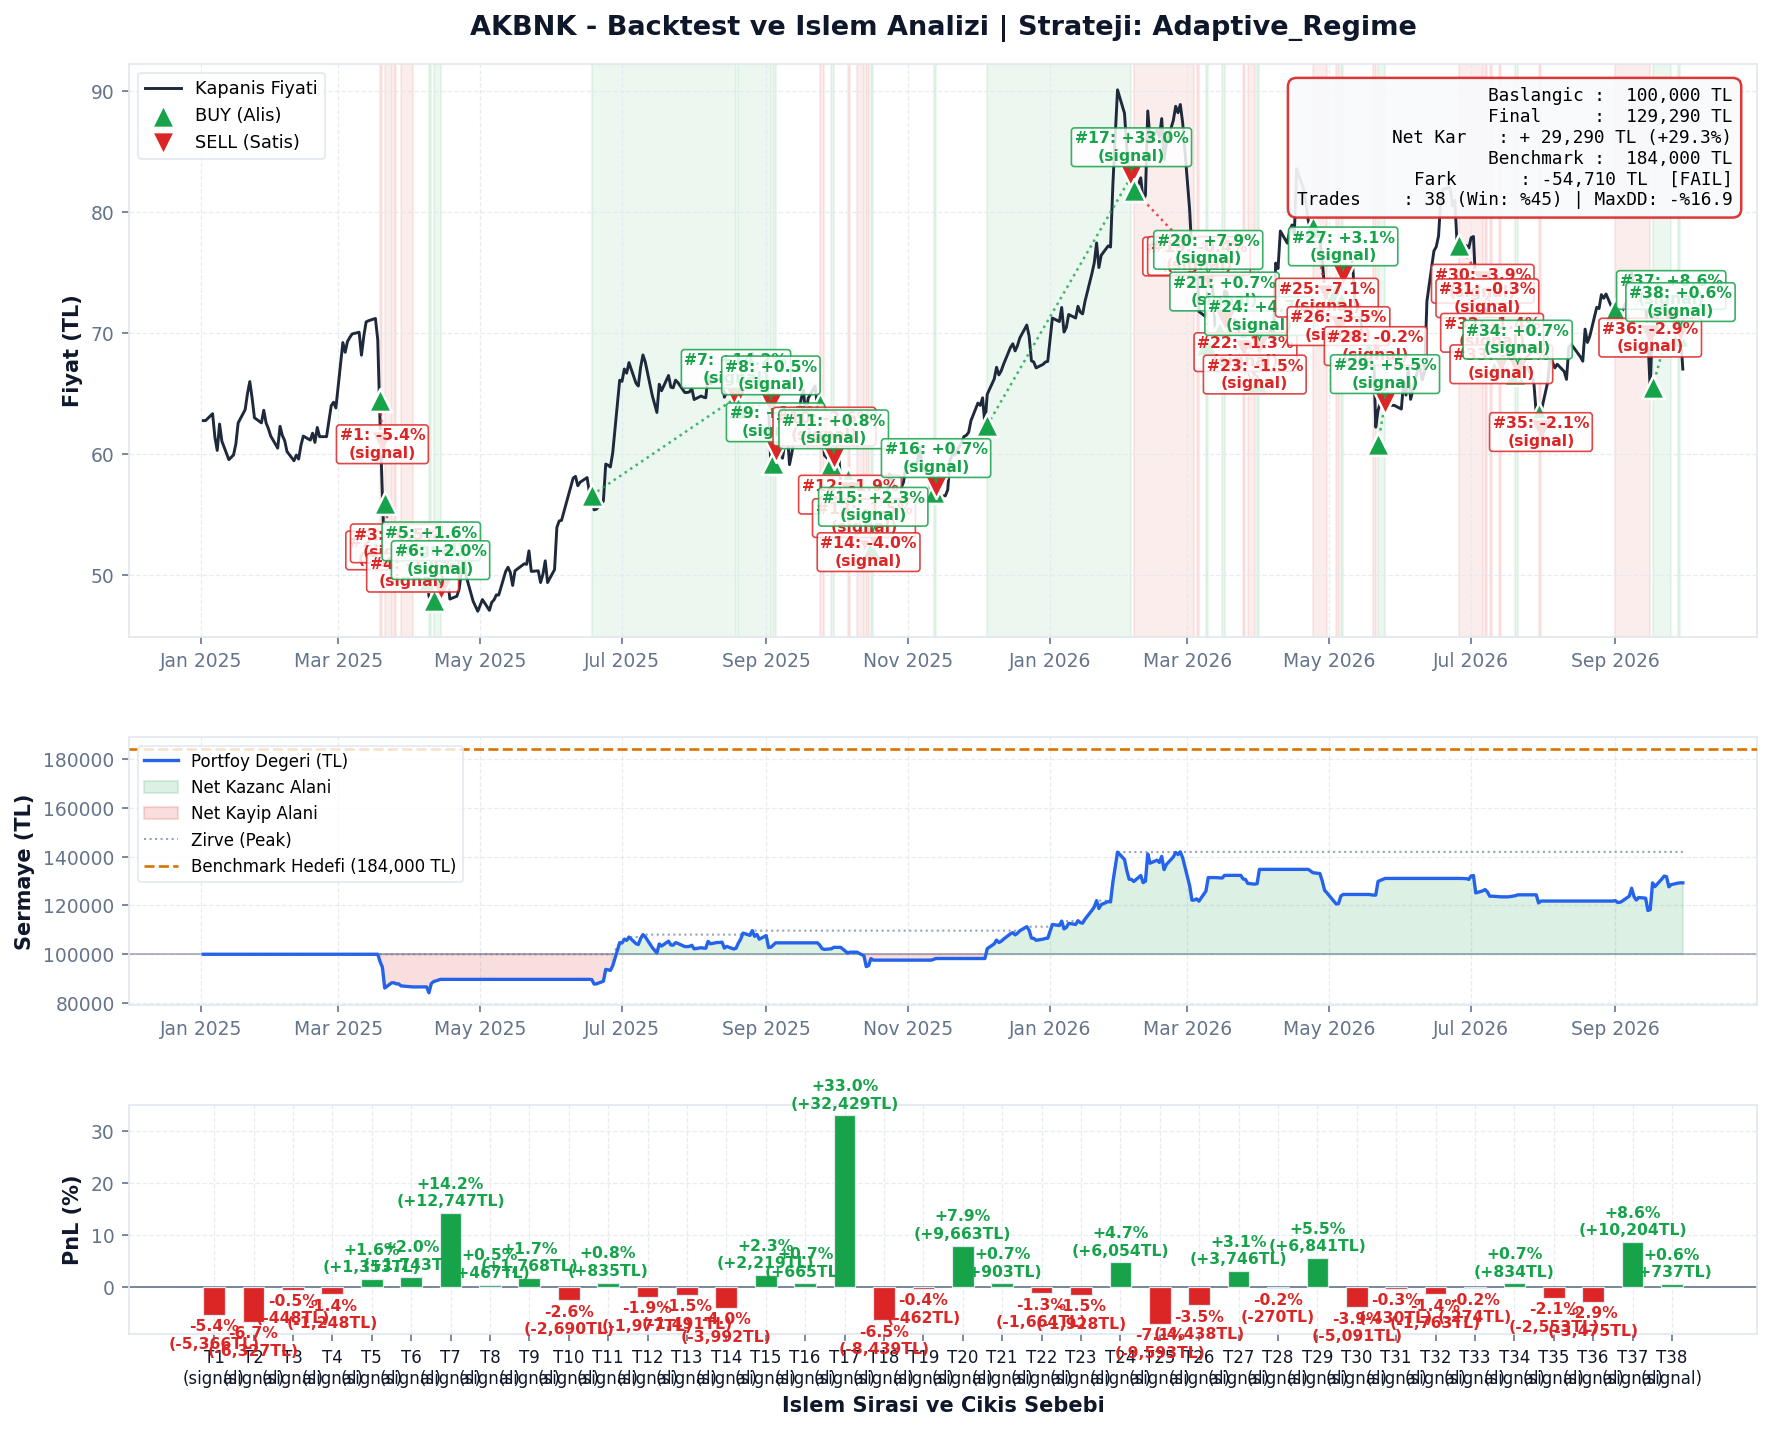

ASELS_dashboard.png


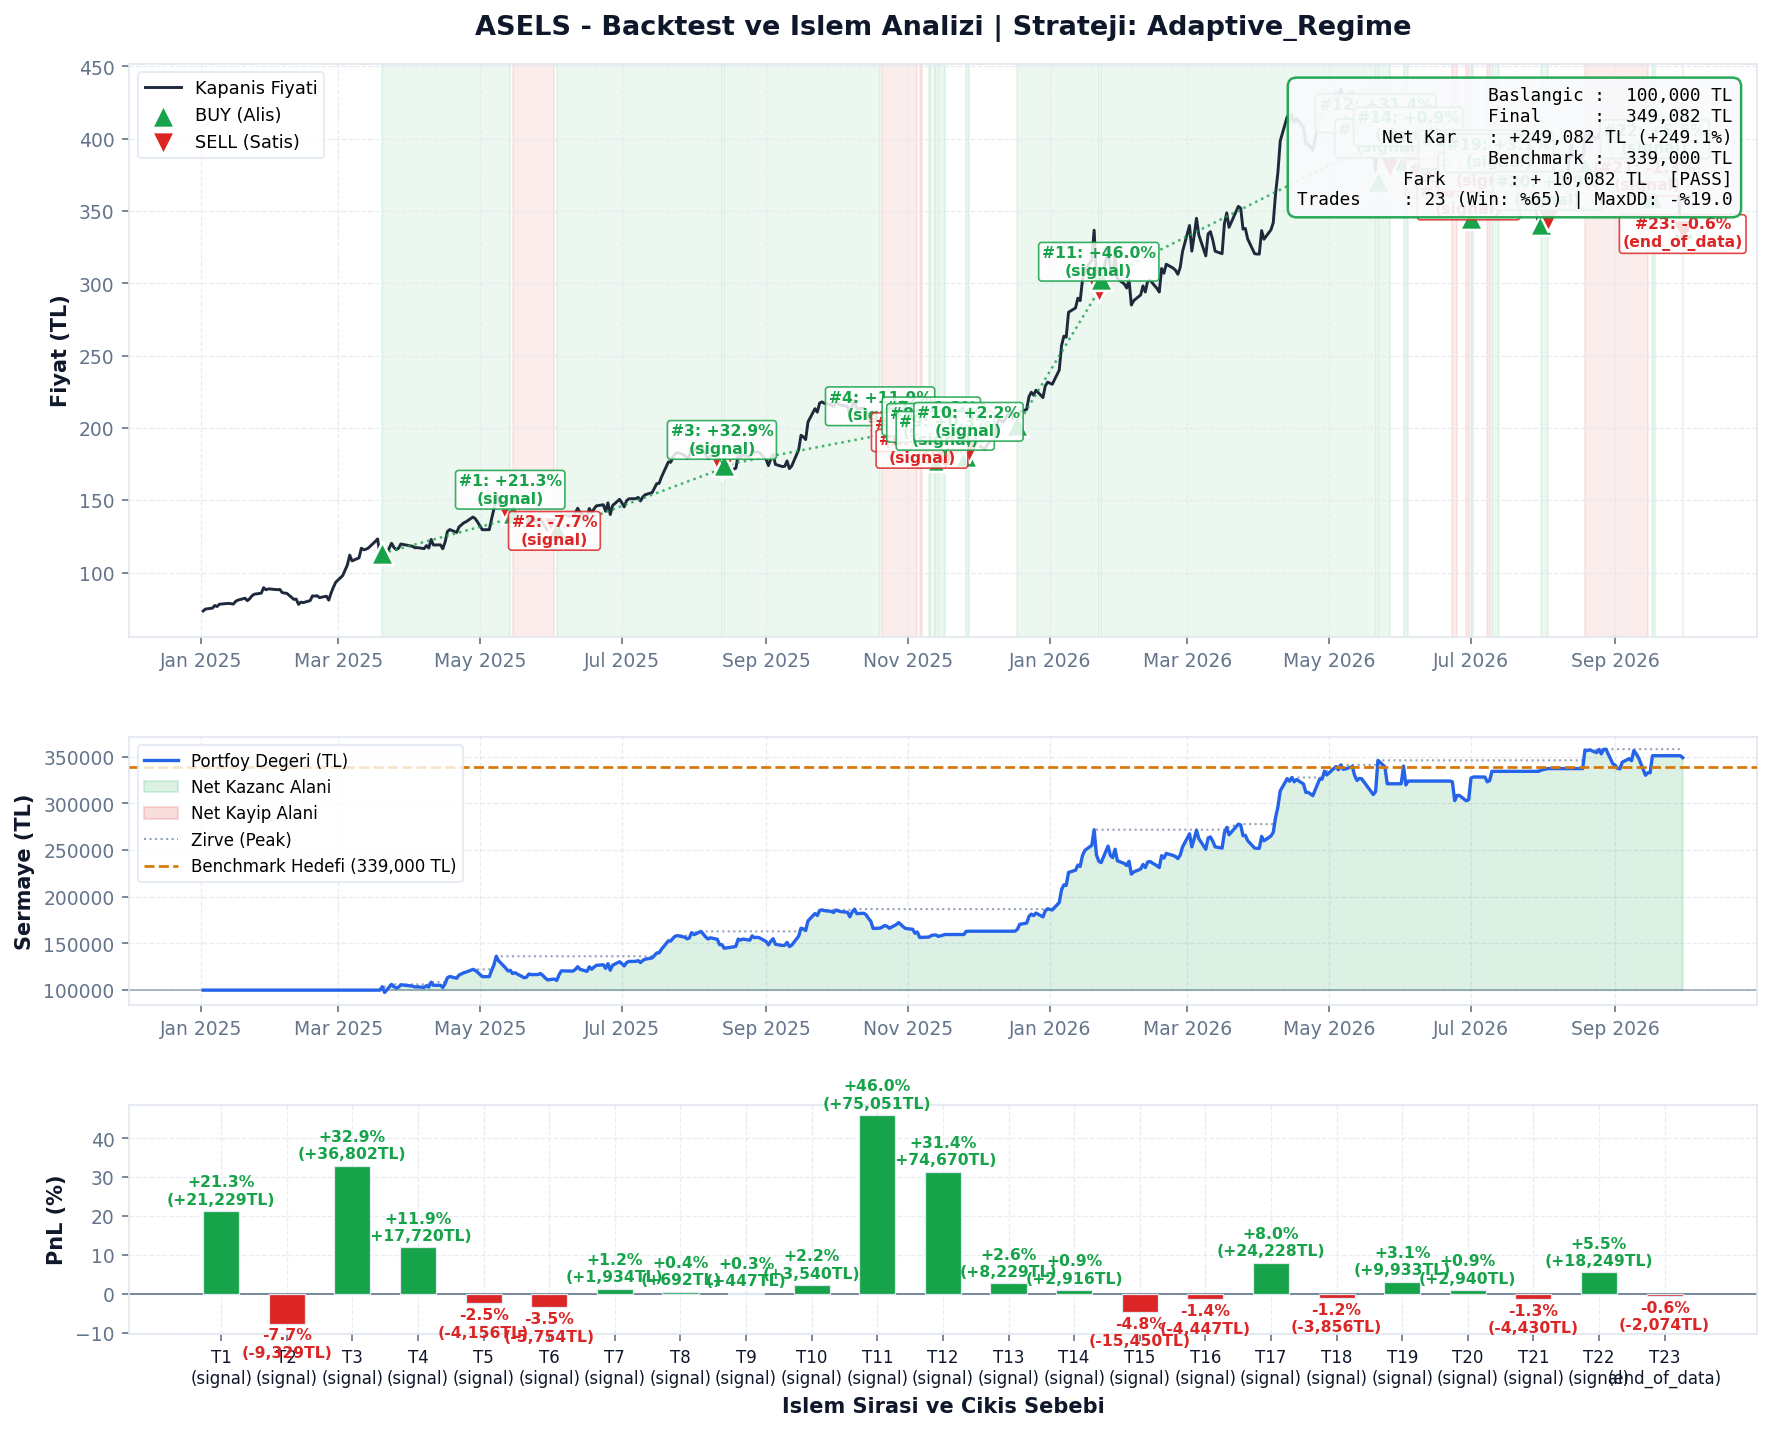

TUPRS_dashboard.png


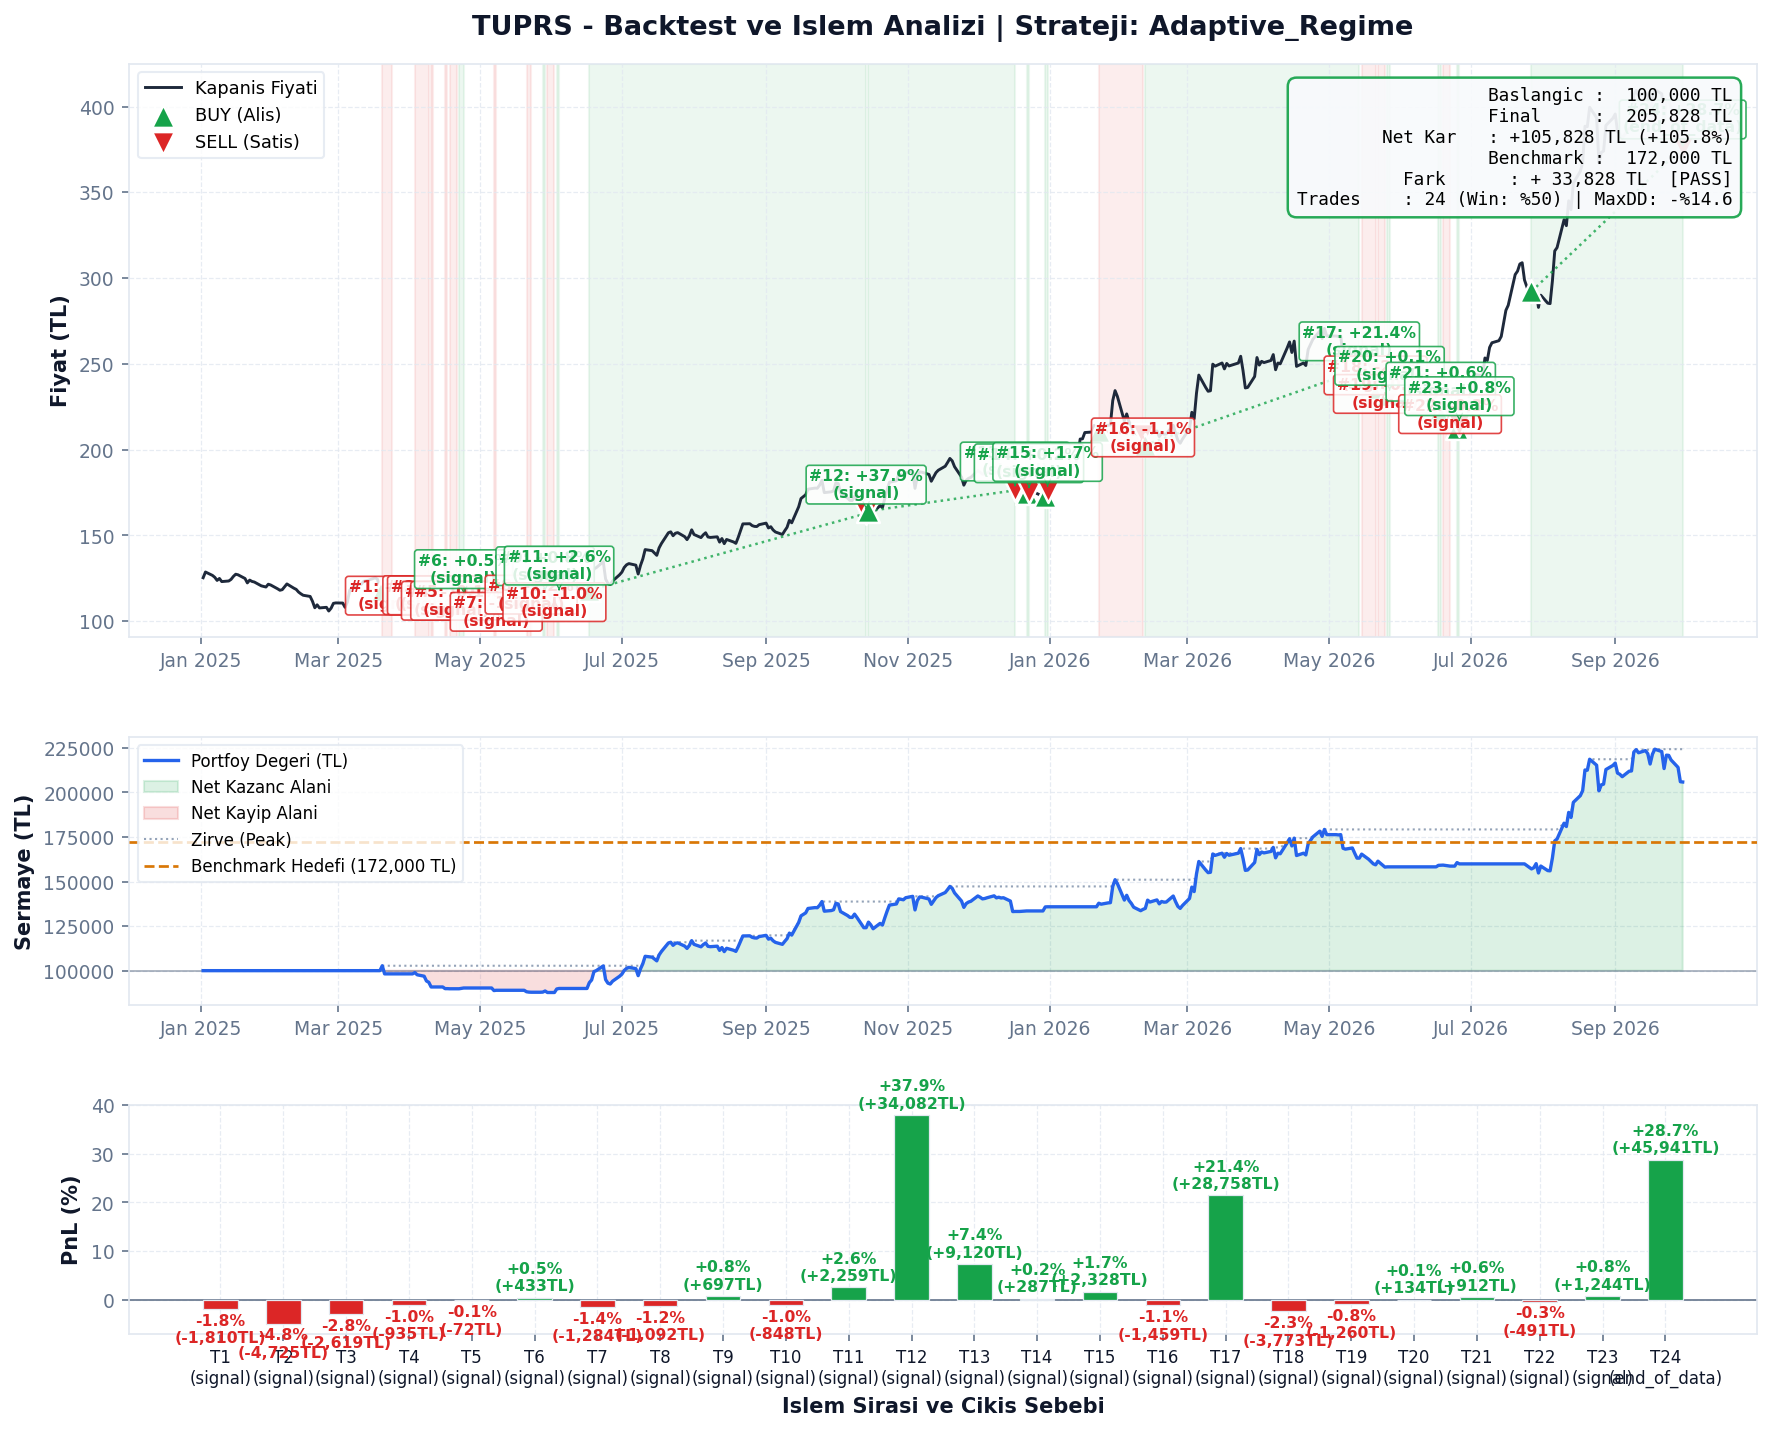

TCELL_dashboard.png


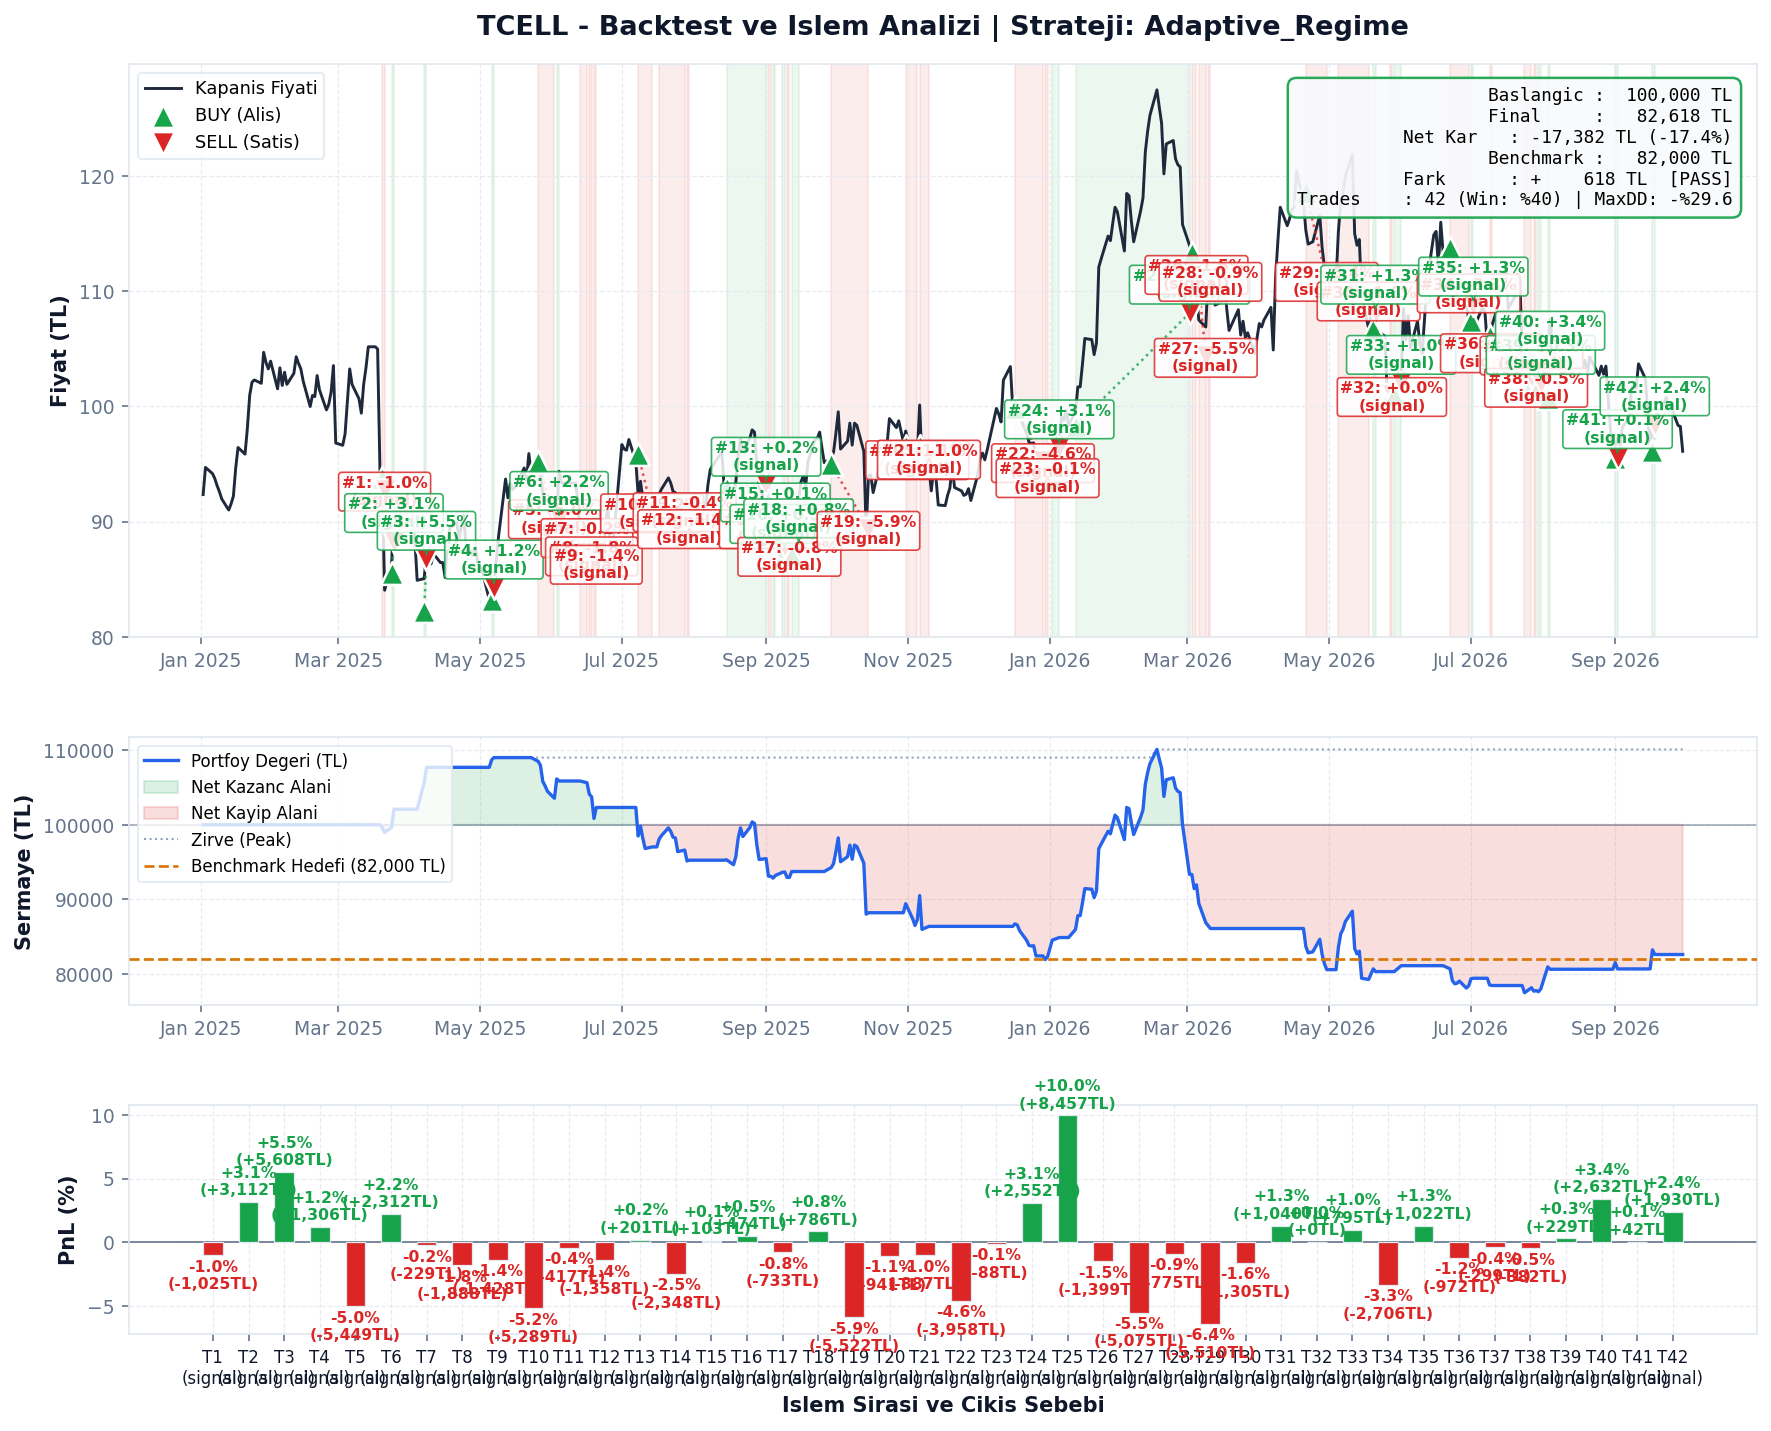

FROTO_dashboard.png


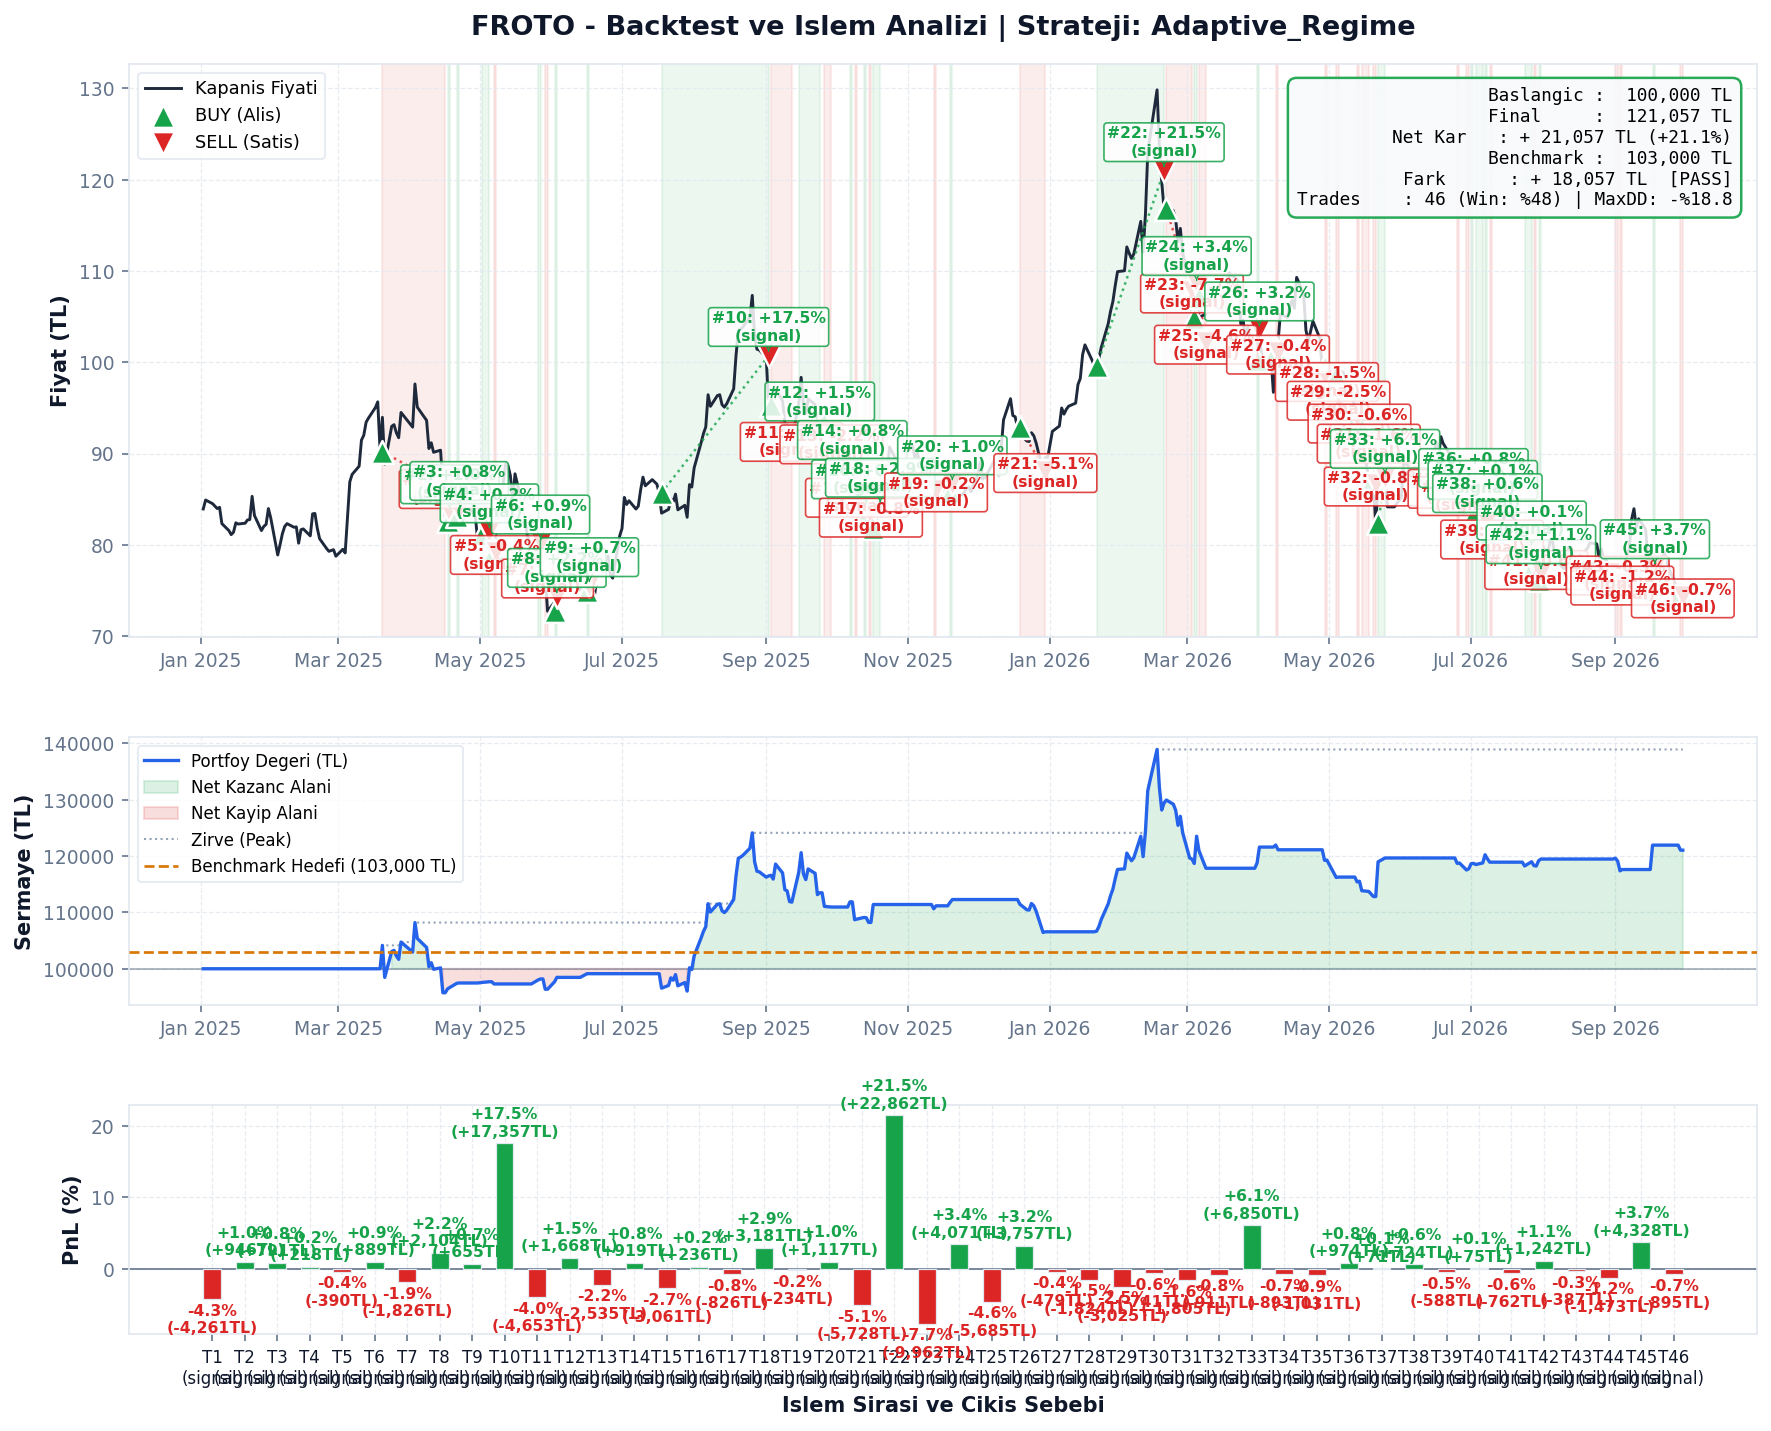

EREGL_dashboard.png


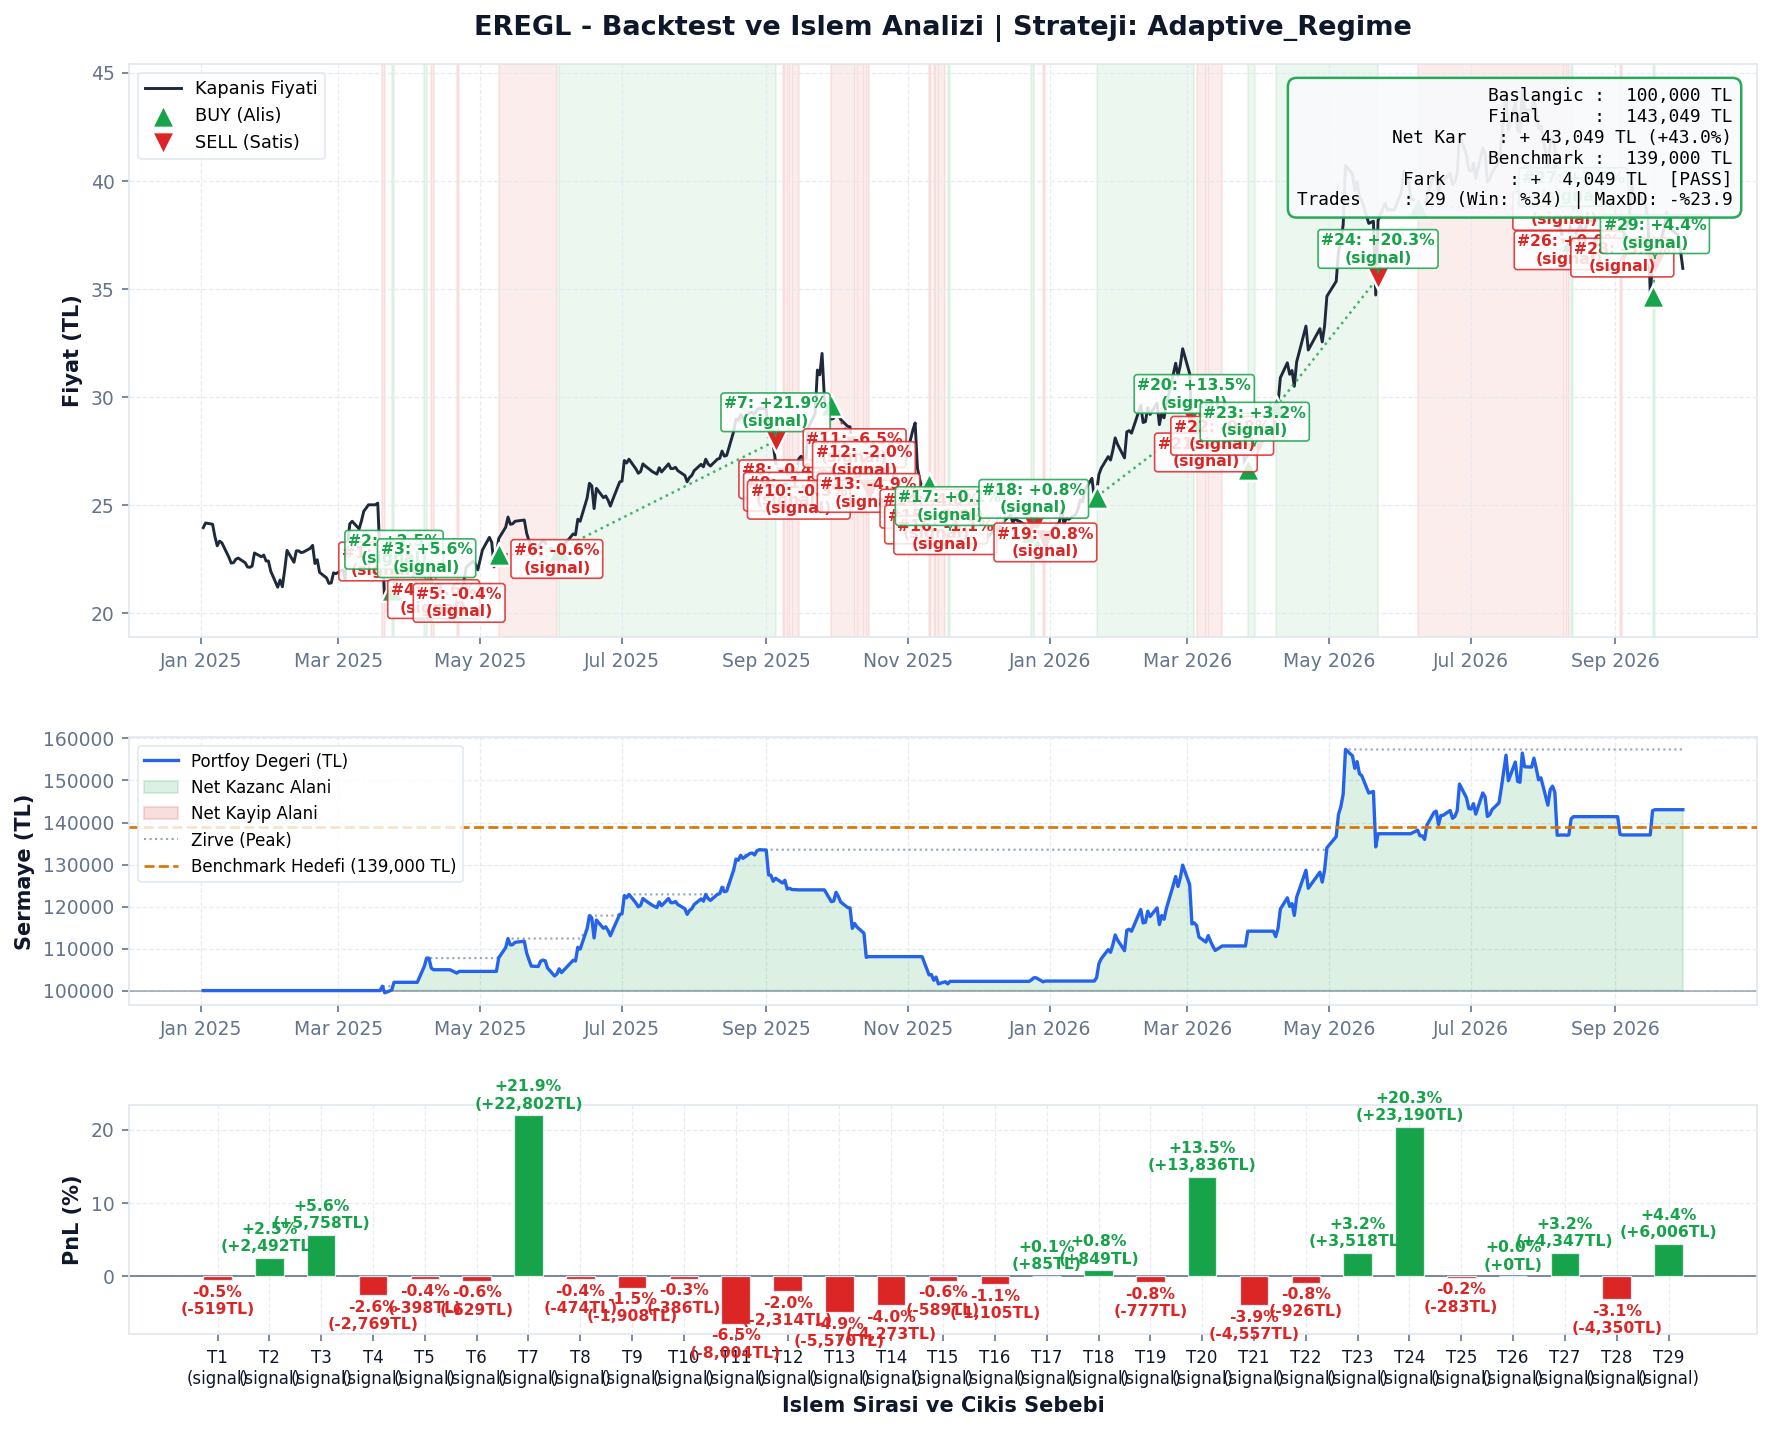

benchmark_comparison.png


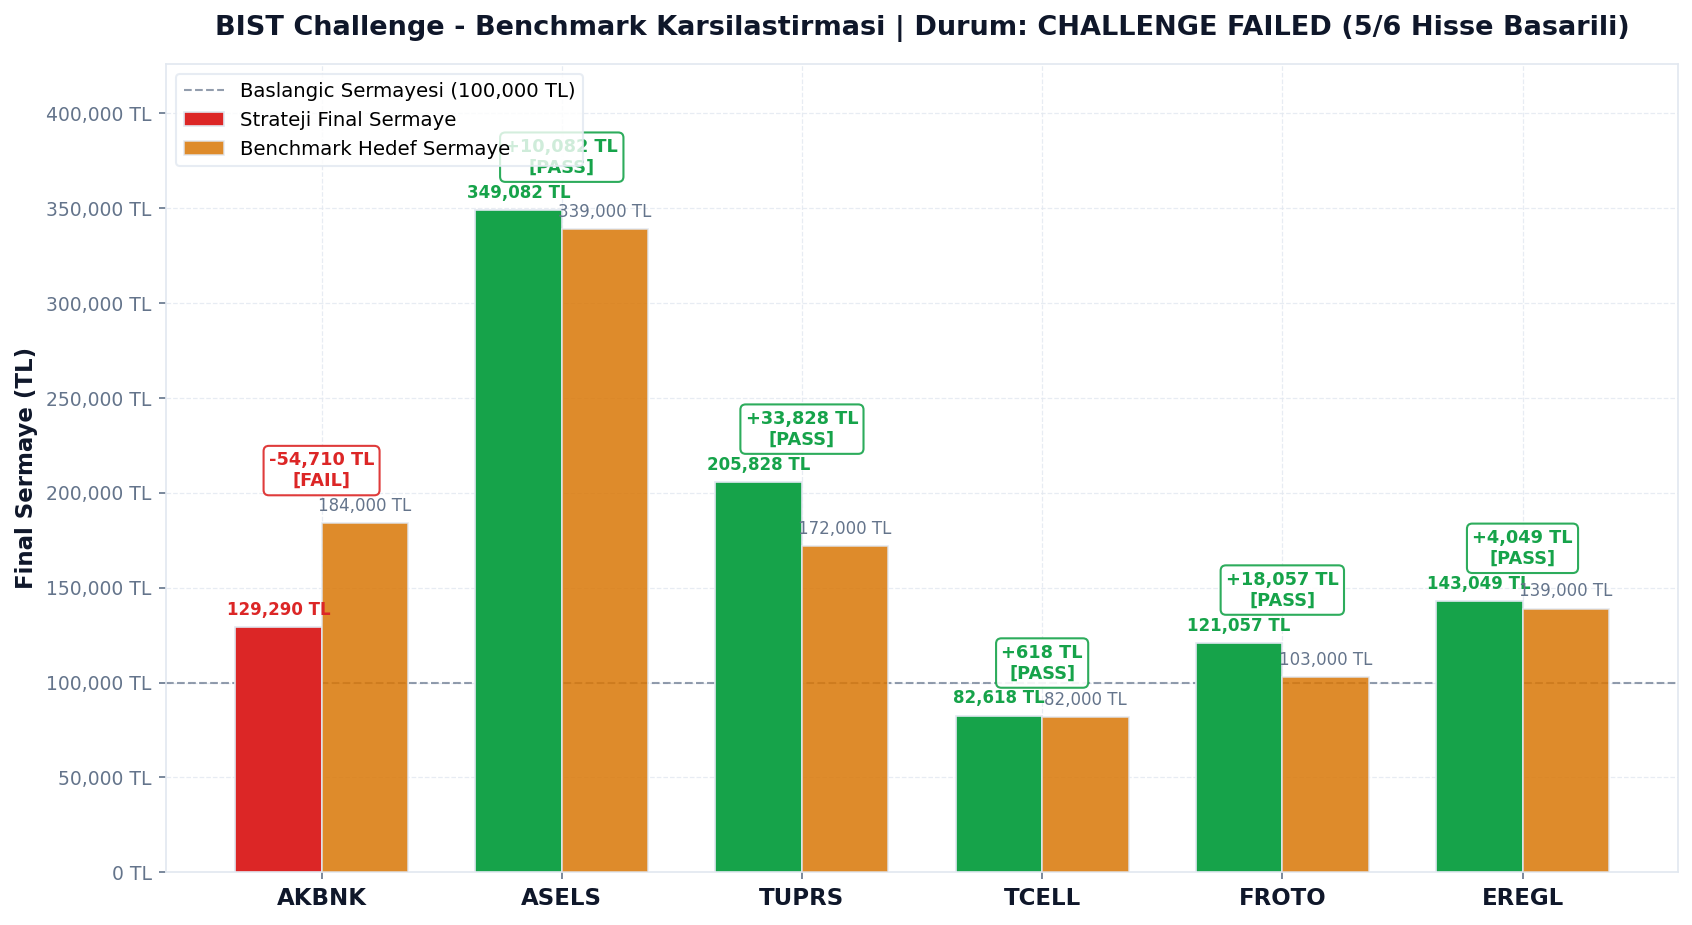

all_equity_curves.png


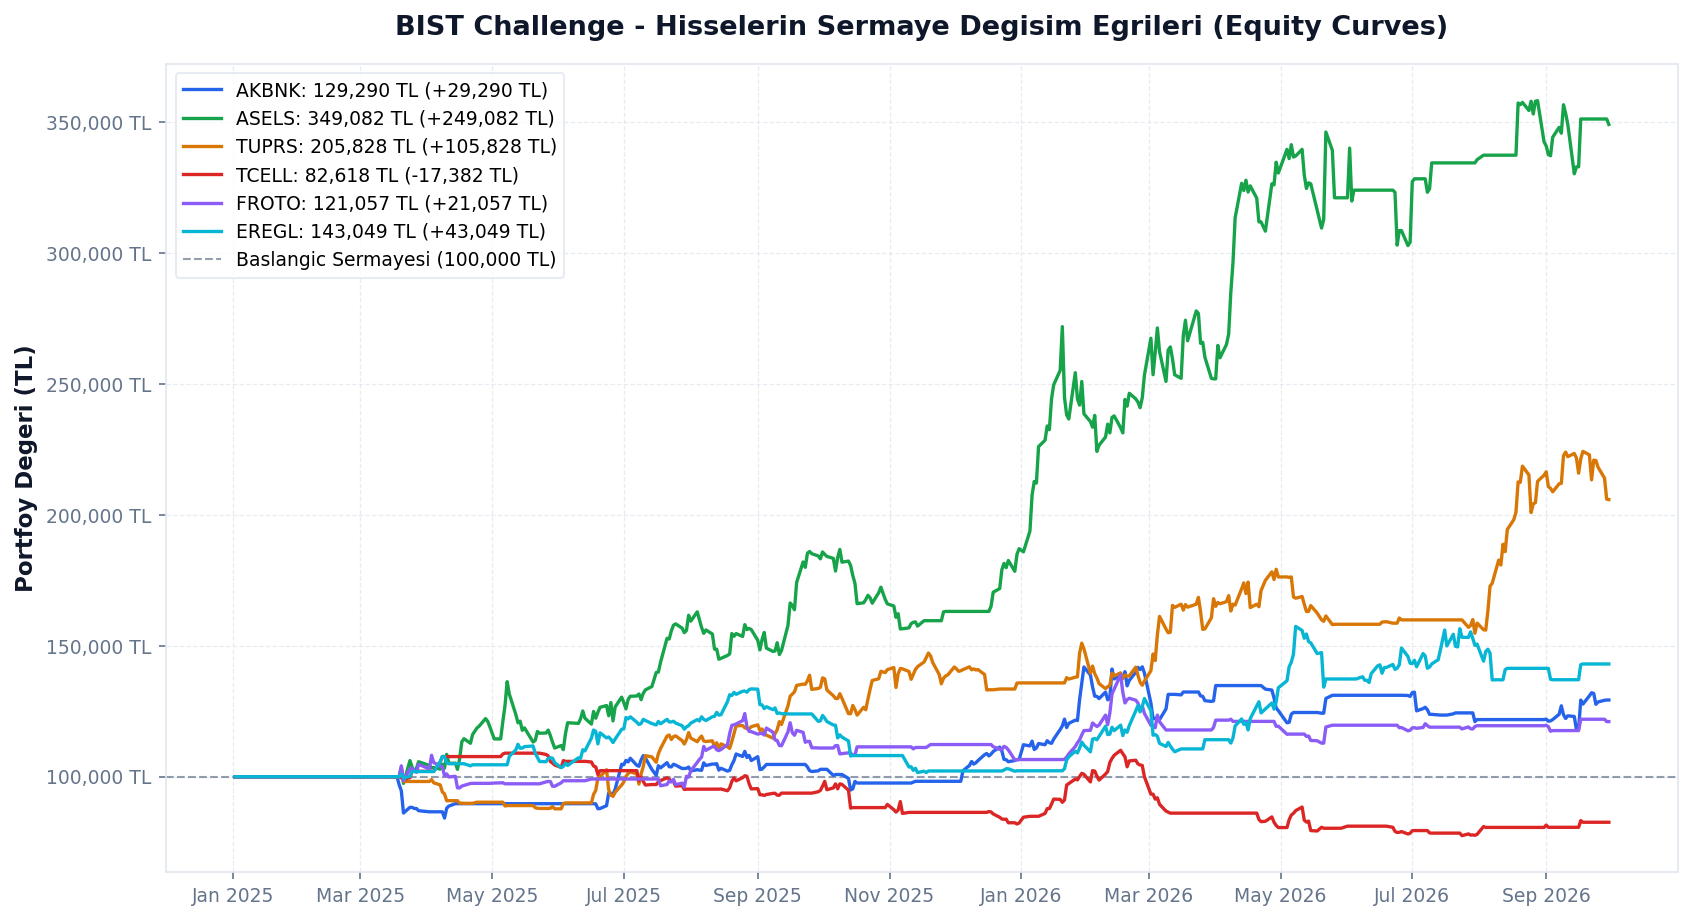

8 grafik notebook içine gömüldü.


In [7]:
chart_paths = [CHARTS_DIR / f"{get_short_name(ticker)}_dashboard.png" for ticker in STOCKS]
chart_paths += [CHARTS_DIR / "benchmark_comparison.png", CHARTS_DIR / "all_equity_curves.png"]
for path in chart_paths:
    payload = path.read_bytes()
    if not payload.startswith(b"\x89PNG\r\n\x1a\n"):
        raise ValueError(f"Geçersiz PNG: {path}")
    print(path.name)
    display({"image/png": base64.b64encode(payload).decode("ascii"),
             "text/plain": f"Grafik: {path.name}"}, raw=True)
print(f"{len(chart_paths)} grafik notebook içine gömüldü.")


## 8. Sonuçları değerlendirme

Her hisse için sermaye hedefi ve üç işlem şartı birlikte kontrol edilmelidir.
Veri kapsamı eksikken görülen benchmark karşılaştırmaları yalnızca mevcut
örneklem içindir. Bir hisse veya dönem iyi sonuç verirken diğerleri kaybedebilir:
trend takibi uzun yönlü hareketleri korumayı, kısa RSI işlemleri yatay piyasada
toparlanmayı yakalamayı amaçlar; güçlü düşüşte geri çekilme girişleri zarar edebilir.

Seçim yaparken yalnızca toplam kârı değil, 2026 alt dönemlerindeki dayanıklılığı,
al-tuta göre farkı, azami düşüşü ve maliyet etkisini birlikte inceleyin. Eksik
1 Ekim verisi doğrulanmadan tam dönem challenge başarısı ilan edilemez.

**Bu dondurulmuş model challenge'ı çözmüş değildir.** Mevcut 440 bar üzerinde
yalnızca 3/6 hisse hedef/işlem şartını sağlar; 600.000 TL toplam sermaye yaklaşık
913.200 TL olur. AKBNK'da tam dönem azami düşüş yaklaşık %50,68 ve 2026 getirisi
yaklaşık -%32,79'dur. Bu zayıflıklar raporlanır; 2026 sonucu görüldükten sonra
model yeniden ayarlanarak bağımsız doğrulama iddiasında bulunulmaz.
